# <u> Curtailement of Renewables <u>

> Authors : Boyina Leena and Ramesh Brian

The aim of this notebook is to present the complete analysis conducted in this project. We investigate the occurrence of negative day-ahead electricity prices in a power system with a high share of renewable energy. Particular attention is paid to their temporal dynamics, underlying fundamental drivers, and their predictability based on information available to market participants.

## <u> Necessary imports </u>

In [1]:
# Standard library
from pathlib import Path
import math
import calendar

# Third-party
import numpy as np
import pandas as pd

# Local modules
import scripts.data as dl
import scripts.plots as pl
import scripts.models as md


## <u> Data load and processing</u>

The data used in this study are obtained from the SMARD website. This section aims to load the data, provide initial insights, and perform the feature engineering required for the remainder of the project.

For the German market, a substantial part of the data—particularly price-related variables is not available on the SMARD platform prior to 2018. We therefore restrict the primary analysis to the period from 2018 to the end of 2025, which provides a sufficiently rich and consistent dataset for the purposes of this study.

In [2]:
import pandas as pd

# Chemin vers ton fichier
file_path = r"C:\Users\luneb\Documents\ENSAE\3A\S2\Economics of energy market\Curtailement-of-Renewables\data\Installed_generation_capacity_hour.csv"

try:
    # 1. Lecture du CSV
    # Note : sep=None avec engine='python' permet de détecter automatiquement si c'est une virgule ou un point-virgule
    df = pd.read_csv(file_path, sep=None, engine='python')

    # 2. Conversion de la colonne temporelle (souvent nécessaire pour l'énergie)
    # Si tu as une colonne 'Date' ou 'Time', décommente la ligne suivante :
    # df['Date'] = pd.to_datetime(df['Date'])

    # 3. Aperçu des données
    print("--- Dimensions du dataset ---")
    print(df.shape)
    print("\n--- 5 premières lignes ---")
    print(df.head())
    print("\n--- Liste des colonnes ---")
    print(df.columns.tolist())

except FileNotFoundError:
    print(f"Erreur : Le fichier n'a pas été trouvé au chemin : {file_path}")
except Exception as e:
    print(f"Une erreur est survenue : {e}")

# Optionnel : Filtrer uniquement les colonnes liées aux renouvelables pour ton étude
# ren_cols = [c for c in df.columns if 'wind' in c.lower() or 'solar' in c.lower()]
# print("\nColonnes EnR détectées :", ren_cols)
df.columns

--- Dimensions du dataset ---
(70152, 14)

--- 5 premières lignes ---
            ﻿Start date             End date  \
0  Jan 1, 2018 12:00 AM  Jan 1, 2018 1:00 AM   
1   Jan 1, 2018 1:00 AM  Jan 1, 2018 2:00 AM   
2   Jan 1, 2018 2:00 AM  Jan 1, 2018 3:00 AM   
3   Jan 1, 2018 3:00 AM  Jan 1, 2018 4:00 AM   
4   Jan 1, 2018 4:00 AM  Jan 1, 2018 5:00 AM   

  Biomass [MW] Calculated resolutions Hydropower [MW] Calculated resolutions  \
0                            7,398.00                                      -   
1                            7,398.00                                      -   
2                            7,398.00                                      -   
3                            7,398.00                                      -   
4                            7,398.00                                      -   

  Wind offshore [MW] Calculated resolutions  \
0                                         -   
1                                         -   
2                  

Index(['﻿Start date', 'End date', 'Biomass [MW] Calculated resolutions',
       'Hydropower [MW] Calculated resolutions',
       'Wind offshore [MW] Calculated resolutions',
       'Wind onshore [MW] Calculated resolutions',
       'Photovoltaics [MW] Calculated resolutions',
       'Other renewable [MW] Calculated resolutions',
       'Nuclear [MW] Calculated resolutions',
       'Lignite [MW] Calculated resolutions',
       'Hard coal [MW] Calculated resolutions',
       'Fossil gas [MW] Calculated resolutions',
       'Hydro pumped storage [MW] Calculated resolutions',
       'Other conventional [MW] Calculated resolutions'],
      dtype='object')

In [3]:
# data load 

data_dir = Path("data")  

path_cons  = data_dir / "Actual_consumption_Hour.csv"
path_gen   = data_dir / "Actual_generation_hour.csv"
path_crossb = data_dir / "Cross-border_physical_flows_hour.csv"
path_tso = data_dir / "Costs_of_TSOs__without_costs_of_DSOs_hour.csv"
path_price = data_dir / "Day-ahead_prices_hour.csv"
path_fcons = data_dir / "Forecasted_consumption_hour.csv"
path_fgen   = data_dir / "Forecasted_generation_Day-Ahead_Hour.csv"
path_instgen = data_dir / "Installed_generation_capacity_hour.csv"

In [4]:
paths = {
    "Consumption": path_cons,
    "Generation": path_gen,
    "Price": path_price,
    "Forecasted Generation": path_fgen,
    "Forecast Consumption": path_fcons,
    "Cross Border": path_crossb,
    "TSO Costs": path_tso,
    "Installed Generation": path_instgen
}

dfs = {name: dl.read_smard_csv(path) for name, path in paths.items()}

print(f"{'Dataset':<22} {'Start date':<20} {'End date':<20}")

for name, df in dfs.items():
    if "Start date" in df.columns:
        start = df["Start date"].min()
        end = df["Start date"].max()
    else:
        start = end = "N/A"
    print(f"{name:<22} {str(start):<20} {str(end):<20}")

# for name, df in dfs.items():
#     print(f"\n{name} columns:")
#     display(df.columns)

Dataset                Start date           End date            
Consumption            2018-01-01 00:00:00  2026-01-01 23:00:00 
Generation             2018-01-01 00:00:00  2026-01-01 23:00:00 
Price                  2018-01-01 00:00:00  2026-01-01 23:00:00 
Forecasted Generation  2018-01-01 00:00:00  2026-01-01 23:00:00 
Forecast Consumption   2018-01-01 00:00:00  2026-01-01 23:00:00 
Cross Border           2018-01-01 00:00:00  2026-01-01 23:00:00 
TSO Costs              2018-01-01 00:00:00  2026-01-01 23:00:00 
Installed Generation   2018-01-01 00:00:00  2026-01-01 23:00:00 


Before this stage, the raw data have not yet been processed and may contain duplicates. These duplicates mainly arise from daylight saving time changes (e.g., the transition between summer and winter time). At this step, we handle these time-related duplicates to ensure a consistent and unambiguous time index.

In [5]:
for name, df_ in dfs.items():
    dup_dates = df_.loc[df_["Start date"].duplicated(), "Start date"]
    print(f"\n{name} duplicated timestamps:")
    print(dup_dates.values)


Consumption duplicated timestamps:
['2018-10-28T02:00:00.000000000' '2019-10-27T02:00:00.000000000'
 '2020-10-25T02:00:00.000000000' '2021-10-31T02:00:00.000000000'
 '2022-10-30T02:00:00.000000000' '2023-10-29T02:00:00.000000000'
 '2024-10-27T02:00:00.000000000' '2025-10-26T02:00:00.000000000']

Generation duplicated timestamps:
['2018-10-28T02:00:00.000000000' '2019-10-27T02:00:00.000000000'
 '2020-10-25T02:00:00.000000000' '2021-10-31T02:00:00.000000000'
 '2022-10-30T02:00:00.000000000' '2023-10-29T02:00:00.000000000'
 '2024-10-27T02:00:00.000000000' '2025-10-26T02:00:00.000000000']

Price duplicated timestamps:
['2018-10-28T02:00:00.000000000' '2019-10-27T02:00:00.000000000'
 '2020-10-25T02:00:00.000000000' '2021-10-31T02:00:00.000000000'
 '2022-10-30T02:00:00.000000000' '2023-10-29T02:00:00.000000000'
 '2024-10-27T02:00:00.000000000' '2025-10-26T02:00:00.000000000']

Forecasted Generation duplicated timestamps:
['2018-10-28T02:00:00.000000000' '2019-10-27T02:00:00.000000000'
 '202

In [6]:
# Check for duplicated timestamps

for name, df_ in dfs.items():
    dup_mask = df_["Start date"].duplicated(keep=False)

    print(f"\n{name} – duplicated rows:")
    
    if dup_mask.any():
        display(df_.loc[dup_mask].sort_values("Start date"))
    else:
        print("No duplicated timestamps")


Consumption – duplicated rows:


,Start date,End date,grid load [MWh] Calculated resolutions,Grid load incl. hydro pumped storage [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
7201,2018-10-28 02:00:00,2018-10-28 03:00:00,41363.50,42633.00,1269.50,27957.75
7202,2018-10-28 02:00:00,2018-10-28 03:00:00,40896.75,43174.50,2277.75,27227.00
15937,2019-10-27 02:00:00,2019-10-27 03:00:00,41796.00,45431.25,3635.25,9090.50
15938,2019-10-27 02:00:00,2019-10-27 03:00:00,41113.00,45010.25,3897.25,8952.50
24673,2020-10-25 02:00:00,2020-10-25 03:00:00,41656.75,43927.75,2271.00,11657.00
24674,2020-10-25 02:00:00,2020-10-25 03:00:00,41052.25,42856.25,1804.00,11099.25
33577,2021-10-31 02:00:00,2021-10-31 03:00:00,41807.25,45129.50,3322.25,22342.25
33578,2021-10-31 02:00:00,2021-10-31 03:00:00,41221.25,44897.75,3676.50,23507.25
42313,2022-10-30 02:00:00,2022-10-30 03:00:00,35357.00,38563.75,3206.75,24082.00
42314,2022-10-30 02:00:00,2022-10-30 03:00:00,34717.00,38314.25,3597.25,23477.50



Generation – duplicated rows:


,Start date,End date,Biomass [MWh] Calculated resolutions,Hydropower [MWh] Calculated resolutions,Wind offshore [MWh] Calculated resolutions,Wind onshore [MWh] Calculated resolutions,Photovoltaics [MWh] Calculated resolutions,Other renewable [MWh] Calculated resolutions,Nuclear [MWh] Calculated resolutions,Lignite [MWh] Calculated resolutions,Hard coal [MWh] Calculated resolutions,Fossil gas [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Other conventional [MWh] Calculated resolutions
7201,2018-10-28 02:00:00,2018-10-28 03:00:00,4722.50,1234.25,2462.00,10943.75,0.00,147.00,8010.25,15835.25,2588.25,3305.00,79.00,1325.50
7202,2018-10-28 02:00:00,2018-10-28 03:00:00,4724.00,1229.25,2247.75,11422.00,0.00,147.00,8011.25,15713.25,2551.75,3337.50,0.00,1316.50
15937,2019-10-27 02:00:00,2019-10-27 03:00:00,4475.75,1266.25,4516.50,28189.00,0.00,173.50,6842.25,4992.50,1279.25,2415.75,1643.50,1120.50
15938,2019-10-27 02:00:00,2019-10-27 03:00:00,4405.00,1346.50,4530.25,27630.25,0.00,172.25,6547.50,4947.75,1239.75,2132.75,1611.50,1122.50
24673,2020-10-25 02:00:00,2020-10-25 03:00:00,4477.00,1628.75,5927.00,24071.75,1.00,165.00,6616.00,4313.00,1611.00,2998.25,1664.50,1217.25
24674,2020-10-25 02:00:00,2020-10-25 03:00:00,4480.75,1619.50,5988.25,23963.75,1.00,165.00,6604.25,4288.50,1421.00,2985.50,1680.50,1204.75
33577,2021-10-31 02:00:00,2021-10-31 03:00:00,4199.75,934.75,2648.50,16816.50,0.00,158.00,7260.75,9287.50,2132.75,2310.25,140.75,1109.75
33578,2021-10-31 02:00:00,2021-10-31 03:00:00,4212.50,1003.25,2546.25,15167.75,0.00,159.00,7247.75,8926.25,1978.25,2362.50,137.50,1156.00
42313,2022-10-30 02:00:00,2022-10-30 03:00:00,4111.50,1317.25,1724.50,9547.50,3.00,132.75,3093.25,11279.25,1584.50,2383.00,48.25,964.00
42314,2022-10-30 02:00:00,2022-10-30 03:00:00,4090.00,1290.50,1844.25,9392.25,3.00,132.25,3096.00,11087.50,1635.50,1906.25,30.25,986.25



Price – duplicated rows:


...

,Start date,End date,Net export [MWh] Calculated resolutions,Netherlands (export) [MWh] Calculated resolutions,Netherlands (import) [MWh] Calculated resolutions,Switzerland (export) [MWh] Calculated resolutions,Switzerland (import) [MWh] Calculated resolutions,Denmark (export) [MWh] Calculated resolutions,Denmark (import) [MWh] Calculated resolutions,Czech Republic (export) [MWh] Calculated resolutions,...,Austria (export) [MWh] Calculated resolutions,Austria (import) [MWh] Calculated resolutions,France (export) [MWh] Calculated resolutions,France (import) [MWh] Calculated resolutions,Poland (export) [MWh] Calculated resolutions,Poland (import) [MWh] Calculated resolutions,Norway (export) [MWh] Calculated resolutions,Norway (import) [MWh] Calculated resolutions,Belgium (export) [MWh] Calculated resolutions,Belgium (import) [MWh] Calculated resolutions
7201,2018-10-28 02:00:00,2018-10-28 03:00:00,NaN,2384.00,0.00,3549.00,0.00,1308.00,0.00,721.00,...,1562.00,-285.00,811.00,-92.00,684.00,0.0,NaN,NaN,NaN,NaN
7202,2018-10-28 02:00:00,2018-10-28 03:00:00,NaN,2479.00,0.00,3485.00,0.00,1556.00,0.00,714.00,...,1637.00,-345.00,858.00,-228.00,678.00,0.0,NaN,NaN,NaN,NaN
15937,2019-10-27 02:00:00,2019-10-27 03:00:00,NaN,1378.00,0.00,2952.00,0.00,1956.00,0.00,1887.00,...,2794.00,-48.00,1075.00,-918.00,1016.00,0.0,NaN,NaN,NaN,NaN
15938,2019-10-27 02:00:00,2019-10-27 03:00:00,NaN,1386.00,0.00,2957.00,0.00,1838.00,0.00,1795.00,...,2710.00,-117.00,874.00,-963.00,920.00,0.0,NaN,NaN,NaN,NaN
24673,2020-10-25 02:00:00,2020-10-25 03:00:00,10122.78,1688.58,-610.21,2529.14,0.00,440.00,-40.00,1321.00,...,2421.33,-108.30,855.57,-327.69,1648.00,0.0,0.00,0.00,0.00,0.00
24674,2020-10-25 02:00:00,2020-10-25 03:00:00,10448.22,1637.40,-761.31,2541.96,0.00,451.00,-40.00,1372.00,...,2534.64,-44.55,986.72,-322.36,1697.00,0.0,0.00,0.00,0.00,0.00
33577,2021-10-31 02:00:00,2021-10-31 03:00:00,5568.28,318.96,0.00,3430.36,0.00,352.25,-707.25,568.00,...,2339.73,-317.52,152.13,-232.02,786.00,0.0,11.75,-12.00,12.71,-12.88
33578,2021-10-31 02:00:00,2021-10-31 03:00:00,3594.27,250.55,-65.42,2965.49,0.00,622.50,-690.75,464.00,...,2169.05,-300.04,0.00,-1220.87,681.00,0.0,111.50,0.00,0.00,-222.93
42313,2022-10-30 02:00:00,2022-10-30 03:00:00,430.35,222.16,-2452.82,1277.90,-91.00,0.00,-1128.75,815.00,...,827.25,-249.25,813.37,0.00,717.00,0.0,0.00,-55.00,710.00,0.00
42314,2022-10-30 02:00:00,2022-10-30 03:00:00,259.99,358.58,-1574.74,929.70,-49.56,0.00,-1214.50,905.00,...,760.50,-262.00,707.03,-3.91,896.00,0.0,6.75,0.00,0.00,-323.38



TSO Costs – duplicated rows:


,Start date,End date,Balancing services [€] Calculated resolutions,Network security of the TSOs [€] Calculated resolutions,Countertrading [€] Calculated resolutions
7201,2018-10-28 02:00:00,2018-10-28 03:00:00,NaN,NaN,NaN
7202,2018-10-28 02:00:00,2018-10-28 03:00:00,NaN,NaN,NaN
15937,2019-10-27 02:00:00,2019-10-27 03:00:00,NaN,NaN,NaN
15938,2019-10-27 02:00:00,2019-10-27 03:00:00,NaN,NaN,NaN
24673,2020-10-25 02:00:00,2020-10-25 03:00:00,47853.17,NaN,NaN
24674,2020-10-25 02:00:00,2020-10-25 03:00:00,47853.17,NaN,NaN
33577,2021-10-31 02:00:00,2021-10-31 03:00:00,236736.95,NaN,NaN
33578,2021-10-31 02:00:00,2021-10-31 03:00:00,236736.95,NaN,NaN
42313,2022-10-30 02:00:00,2022-10-30 03:00:00,161767.72,287127.01,NaN
42314,2022-10-30 02:00:00,2022-10-30 03:00:00,161767.72,287127.01,NaN



Installed Generation – duplicated rows:


,Start date,End date,Biomass [MW] Calculated resolutions,Hydropower [MW] Calculated resolutions,Wind offshore [MW] Calculated resolutions,Wind onshore [MW] Calculated resolutions,Photovoltaics [MW] Calculated resolutions,Other renewable [MW] Calculated resolutions,Nuclear [MW] Calculated resolutions,Lignite [MW] Calculated resolutions,Hard coal [MW] Calculated resolutions,Fossil gas [MW] Calculated resolutions,Hydro pumped storage [MW] Calculated resolutions,Other conventional [MW] Calculated resolutions
7201,2018-10-28 02:00:00,2018-10-28 03:00:00,7398.0,NaN,NaN,51787.0,42805.0,NaN,NaN,NaN,NaN,31331.0,NaN,NaN
7202,2018-10-28 02:00:00,2018-10-28 03:00:00,7398.0,NaN,NaN,51787.0,42805.0,NaN,NaN,NaN,NaN,31331.0,NaN,NaN
15937,2019-10-27 02:00:00,2019-10-27 03:00:00,7782.0,NaN,NaN,52946.0,45435.0,NaN,NaN,NaN,NaN,31745.0,NaN,NaN
15938,2019-10-27 02:00:00,2019-10-27 03:00:00,7782.0,NaN,NaN,52946.0,45435.0,NaN,NaN,NaN,NaN,31745.0,NaN,NaN
24673,2020-10-25 02:00:00,2020-10-25 03:00:00,7902.0,NaN,NaN,53338.0,47924.0,NaN,NaN,NaN,NaN,31793.0,NaN,NaN
24674,2020-10-25 02:00:00,2020-10-25 03:00:00,7902.0,NaN,NaN,53338.0,47924.0,NaN,NaN,NaN,NaN,31793.0,NaN,NaN
33577,2021-10-31 02:00:00,2021-10-31 03:00:00,8428.0,NaN,NaN,54494.0,7265112.0,NaN,NaN,NaN,NaN,32038.0,NaN,NaN
33578,2021-10-31 02:00:00,2021-10-31 03:00:00,8428.0,NaN,NaN,54494.0,7265112.0,NaN,NaN,NaN,NaN,32038.0,NaN,NaN
42313,2022-10-30 02:00:00,2022-10-30 03:00:00,8379.0,4994.0,NaN,55456.0,58002.0,NaN,NaN,NaN,NaN,30649.0,9379.0,NaN
42314,2022-10-30 02:00:00,2022-10-30 03:00:00,8379.0,4994.0,NaN,55456.0,58002.0,NaN,NaN,NaN,NaN,30649.0,9379.0,NaN


By inspection, we observe that for some variables (e.g., prices) duplicate timestamps are associated with different values, while for others the values remain identical. To aggregate these observations, we take the mean, which appears to be the most appropriate proxy for the value at a given hour. Although alternative choices could be considered, for instance, summing certain variables such as load, we adopt a simple and consistent approach, as the analysis is conducted at an hourly resolution.

In [7]:
dfs_clean = {}

for name, df_ in dfs.items():
    df_clean = (
        df_
        .groupby("Start date", as_index=False)
        .mean(numeric_only=True)
    )
    dfs_clean[name] = df_clean

This preprocessing step aims to align and merge the different SMARD datasets into a single hourly time series while preserving the original structure of the data. All datasets are indexed using the `Start date` timestamp and merged along a common time axis. Column names are standardized to improve readability and ensure consistency across data sources. A left-join strategy is applied, using prices as the reference series, so that all price observations are retained and missing values in auxiliary datasets remain explicit.

In [8]:
df = dl.preprocess_full(
    cons_df=dfs_clean["Consumption"],
    gen_df=dfs_clean["Generation"],
    price_df=dfs_clean["Price"],
    fcons_df=dfs_clean["Forecast Consumption"],
    fgen_df=dfs_clean["Forecasted Generation"],
    crossb_df=dfs_clean["Cross Border"],
    instgen_df=dfs_clean["Installed Generation"]
)
    
display(df.head(3))

,price,price_de_lu,Belgium [€/MWh] Calculated resolutions,price_dk1,Denmark 2 [€/MWh] Calculated resolutions,price_fr,price_nl,Norway 2 [€/MWh] Calculated resolutions,price_at,price_pl,...,cap_wind_off,cap_wind_on,cap_solar,cap_other_res,cap_nuclear,cap_lignite,cap_coal,cap_gas,cap_hydro_pumped,cap_other_conv
Start date,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,NaN,NaN,14.16,21.80,26.33,6.74,27.2,26.33,NaN,NaN,...,NaN,51787.0,42805.0,NaN,NaN,NaN,NaN,31331.0,NaN,NaN
2018-01-01 01:00:00,NaN,NaN,4.74,26.43,26.43,4.74,27.3,26.43,NaN,NaN,...,NaN,51787.0,42805.0,NaN,NaN,NaN,NaN,31331.0,NaN,NaN
2018-01-01 02:00:00,NaN,NaN,3.66,26.10,26.10,3.66,30.1,26.10,NaN,NaN,...,NaN,51787.0,42805.0,NaN,NaN,NaN,NaN,31331.0,NaN,NaN


In [9]:
df.columns

Index(['price', 'price_de_lu', 'Belgium [€/MWh] Calculated resolutions',
       'price_dk1', 'Denmark 2 [€/MWh] Calculated resolutions', 'price_fr',
       'price_nl', 'Norway 2 [€/MWh] Calculated resolutions', 'price_at',
       'price_pl', 'Sweden 4 [€/MWh] Calculated resolutions', 'price_ch',
       'Czech Republic [€/MWh] Calculated resolutions',
       'DE/AT/LU [€/MWh] Calculated resolutions',
       'Northern Italy [€/MWh] Calculated resolutions',
       'Slovenia [€/MWh] Calculated resolutions',
       'Hungary [€/MWh] Calculated resolutions', 'load', 'load_incl_pumped',
       'pumped_consumption', 'residual_load_tso', 'biomass', 'hydro',
       'wind_off', 'wind_on', 'solar', 'other_res', 'nuclear', 'lignite',
       'coal', 'gas', 'hydro_pumped', 'other_conv', 'load_forecast',
       'residual_load_forecast_tso', 'total_generation_forecast',
       'vre_forecast_total', 'wind_off_forecast', 'wind_on_forecast',
       'solar_forecast', 'Other [MWh] Original resolutions',
    

In [10]:
yearly_summary = (
    df.assign(year=df.index.year)
      .groupby("year")
      .agg(
          n_hours=("price", "size"),
          price_na_share=("price", lambda x: x.isna().mean()),
          neg_price_share=("price", lambda x: (x < 0).mean())
      )
)

yearly_summary

,n_hours,price_na_share,neg_price_share
year,,,
2018,8759,0.747916,0.003083
2019,8759,0.000000,0.023975
2020,8783,0.000000,0.033929
2021,8759,0.000000,0.015869
2022,8759,0.000000,0.007878
2023,8759,0.000000,0.034365
2024,8783,0.000000,0.052032
2025,8759,0.000000,0.065418
2026,24,0.000000,0.083333


In [11]:
start_date = df["price"].first_valid_index() # Timestamp('2018-10-01 00:00:00')
start_date
df.loc[start_date:, "price"].isna().any()


missing_share_after_start = (
    df.loc[start_date:]
      .isna()
      .mean()
      .sort_values(ascending=False)
      .to_frame(name="missing_share")
)

missing_share_after_start[
    missing_share_after_start["missing_share"] > 0.00
]

,missing_share
cap_nuclear,1.000000
DE/AT/LU [€/MWh] Calculated resolutions,1.000000
cap_wind_off,0.723775
cap_other_conv,0.723775
cap_lignite,0.723775
cap_coal,0.583775
cap_other_res,0.583775
cap_hydro,0.446417
cap_hydro_pumped,0.446417
net_export_total,0.273709


Note that several columns exhibit a relatively high number of missing values. At this stage, we retain these variables to gain preliminary insights into the data, with the understanding that they may be removed later if deemed uninformative or problematic.

At this stage, the objective is to construct a clear and interpretable dataset that can be used both for exploratory analysis and for modeling negative electricity price events. Feature engineering focuses on aggregating generation by technology, building key physical indicators such as residual load and the generation–load balance, and creating forecast-based variables that reflect expected supply conditions. A binary target variable indicating the occurrence of negative prices is also defined. Basic time effects are introduced through a cyclical representation of the hour of the day and a weekend indicator. This allows daily and weekly patterns to be captured without adding unnecessary complexity. Two datasets are then retained: a complete feature-enriched dataset for visualization and descriptive analysis, and a reduced dataset containing only the variables used for modeling. The final set of variables emphasizes prices, demand, the generation mix, cross-border flows through net exports, forecast-based imbalance measures, and simple time indicators. Variables that are redundant or weakly informative are intentionally excluded in order to keep the model interpretable and limit collinearity.

In [12]:
df_final = dl.add_features(df) # Feature engineering process

df_plot = df_final.copy()

keep_cols = [
    # --- Target & Prices ---
    "price", "price_de_lu", "price_fr", "price_nl", "price_at",
    "price_pl", "price_dk1", "price_ch", "is_negative",

    # --- Demand & System State ---
    "load", "load_incl_pumped", "pumped_consumption", "residual_load_tso",
    "net_export_total", "generation_load_balance",

    # --- Generation Real (Actuals) ---
    "nuclear", "biomass", "lignite", "coal", "gas",
    "hydro_pumped", "hydro", "wind_off", "wind_on", "solar",
    "other_res", "other_conv",
    "wind_total", "renewable_total", "thermal_total", "vre_real_total",

    # --- Installed Capacity (MW) ---
    # Essentiel pour savoir si on est au max de ce qu'on peut produire
    "cap_wind_on", "cap_wind_off", "cap_solar", "cap_biomass", "cap_nuclear",

    # --- Forecasts ---
    "load_forecast", "residual_load_forecast_tso",
    "wind_off_forecast", "wind_on_forecast", "solar_forecast",
    "vre_forecast_total", "total_generation_forecast",
    "wind_forecast_total", "residual_load_forecast",
    "vre_penetration_forecast",

    # --- Curtailment Analysis (Engineered) ---
    "curtailment_raw_gap",       # L'écart théorique forecast - réel
    "curtailment_mwh",           # L'estimation finale du curtailment
    "is_curtailment_likely",     # Flag binaire (prix bas + gap positif)
    "wind_capacity_factor",      # % d'utilisation du vent
    "solar_capacity_factor",     # % d'utilisation du solaire

    # --- Time features ---
    "hour_sin", "hour_cos", "is_weekend", "weekday", "hour"
]

keep_cols = [c for c in keep_cols if c in df_final.columns]
df_model = df_final[keep_cols].copy()
df_plot = df_final[keep_cols].copy()

# Visualisation and first conclusions 

In [13]:
start_date = pd.Timestamp("2023-01-01")
df_modeling = df_model.loc[start_date:].copy()

In [14]:
# Est-ce qu'on a trouvé du curtailment ?
print(f"Nombre de moments avec curtailment probable : {df_modeling['is_curtailment_likely'].sum()}")

# Regarde à quoi ça ressemble quand ça arrive
curtailment_events = df_modeling[df_modeling['is_curtailment_likely'] == 1]
print(curtailment_events[['price', 'curtailment_mwh', 'wind_on', 'wind_on_forecast']].head())

Nombre de moments avec curtailment probable : 1632
                     price  curtailment_mwh   wind_on  wind_on_forecast
Start date                                                             
2023-01-01 00:00:00  -5.17          6985.50  28947.25          35515.50
2023-01-01 01:00:00  -1.07          5559.25  29587.50          35344.50
2023-01-01 02:00:00  -1.47          5175.50  29514.75          35138.75
2023-01-01 03:00:00  -5.08          6892.50  27493.50          34441.00
2023-01-01 04:00:00  -4.49          6925.75  26939.00          33898.00


Les corrélations positives confirment que le curtailment est intrinsèquement lié à l'abondance des énergies renouvelables et aux signaux de prix du marché. La forte corrélation avec la variable is_negative (0.60) valide l'approche économique : le curtailement agit comme une réponse directe aux prix de marché nuls ou négatifs signalant un surplus d'offre. Par ailleurs, la relation significative avec la pénétration prévisionnelle des EnR (vre_penetration_forecast, 0.38) et le pompage hydraulique (pumped_consumption, 0.23) démontre une hiérarchie dans la gestion du réseau. Le phénomène survient lorsque l'offre météo dépasse les capacités d'absorption du système, et ce, malgré la mobilisation préalable des leviers de stockage (batteries et barrages), confirmant que le curtailement est le levier de dernier recours pour maintenir la stabilité physique.

In [15]:
# Quelles colonnes sont les plus liées au curtailment ?
correlations = df_model.corr()['curtailment_mwh'].sort_values(ascending=False)
print(correlations.head(10))

curtailment_mwh             1.000000
is_curtailment_likely       0.764606
is_negative                 0.604016
curtailment_raw_gap         0.511291
vre_penetration_forecast    0.387413
vre_forecast_total          0.327086
vre_real_total              0.268908
renewable_total             0.265407
pumped_consumption          0.232641
wind_on_forecast            0.227477
Name: curtailment_mwh, dtype: float64


À l'inverse, les corrélations négatives soulignent le rôle déterminant des contraintes physiques et de l'inflexibilité du mix électrique. La variable la plus corrélée négativement, la charge résiduelle (residual_load_forecast, -0.36), est le principal prédicteur du phénomène : plus la demande nette est faible (proche de zéro ou négative), plus le curtailement devient inévitable pour éviter la surcharge. La corrélation négative avec le lignite (-0.26) illustre parfaitement le problème du "minimum technique" ou "must-run" en Allemagne : ces centrales thermiques rigides ne peuvent pas s'effacer totalement devant le vent ou le soleil, forçant ainsi les parcs EnR à s'arrêter. Enfin, la corrélation inverse avec le prix (-0.18) et le gaz (-0.17) rappelle que le curtailment est absent lors des périodes de rareté relative, où les sources flexibles et coûteuses sont appelées à produire pour satisfaire une demande robuste.

In [16]:
# Les corrélations les plus négatives (les facteurs qui "empêchent" le curtailment)
print(correlations.tail(10))

gas                          -0.178266
price_nl                     -0.180088
price_pl                     -0.180903
price                        -0.187292
thermal_total                -0.208395
lignite                      -0.263268
residual_load_tso            -0.309861
residual_load_forecast       -0.362593
residual_load_forecast_tso   -0.362593
cap_nuclear                        NaN
Name: curtailment_mwh, dtype: float64


# plots

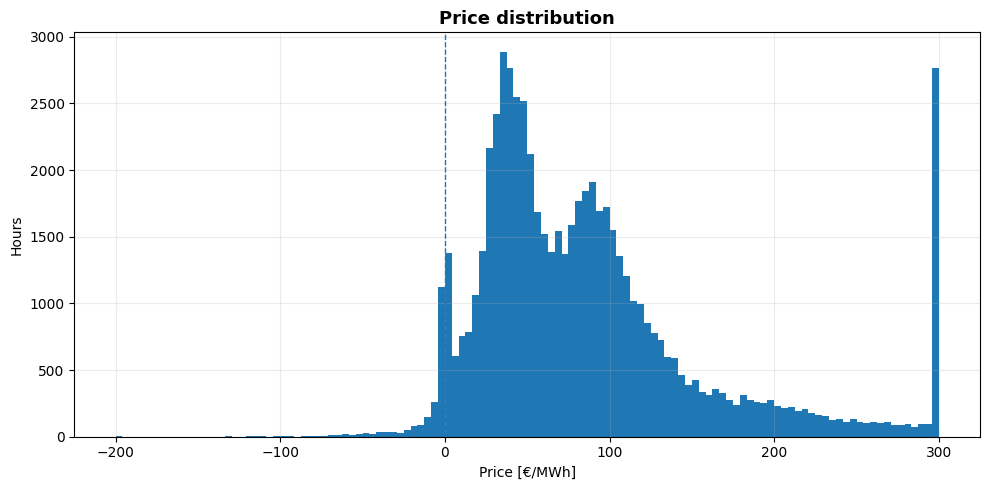

'plots/curtailment\\price_distribution.png'

In [17]:
# 1. Distribution du prix : Pour montrer la fréquence des prix négatifs (contexte)
pl.plot_price_distribution(df_model)

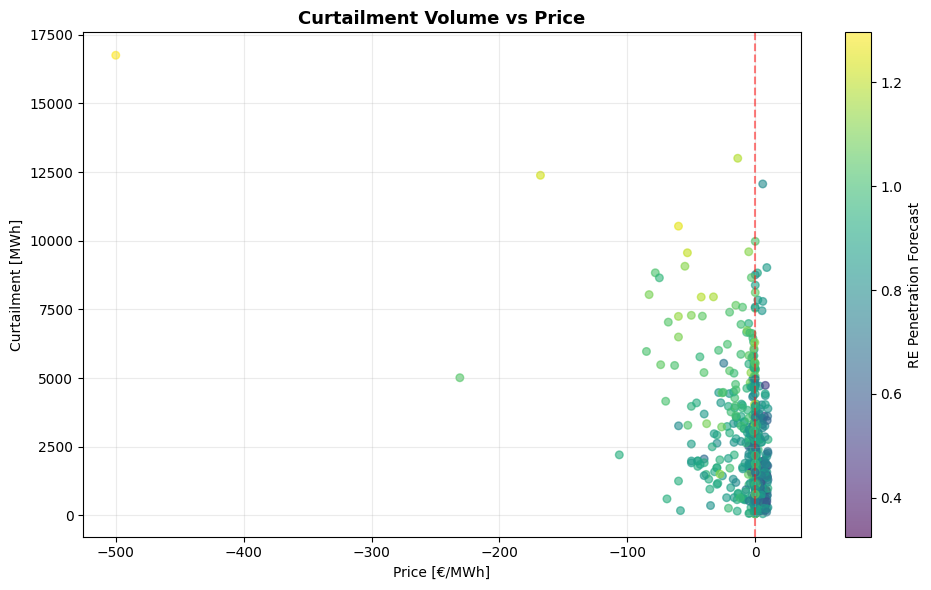

'plots/curtailment\\curtailment_vs_price.png'

In [18]:
# 2. Corrélation Prix/Curtailment : Pour répondre à "Under which conditions?" (Économie)
# On s'attend à voir le curtailment exploser quand le prix passe sous 0.
pl.plot_curtailment_v_price_scatter(df_model)


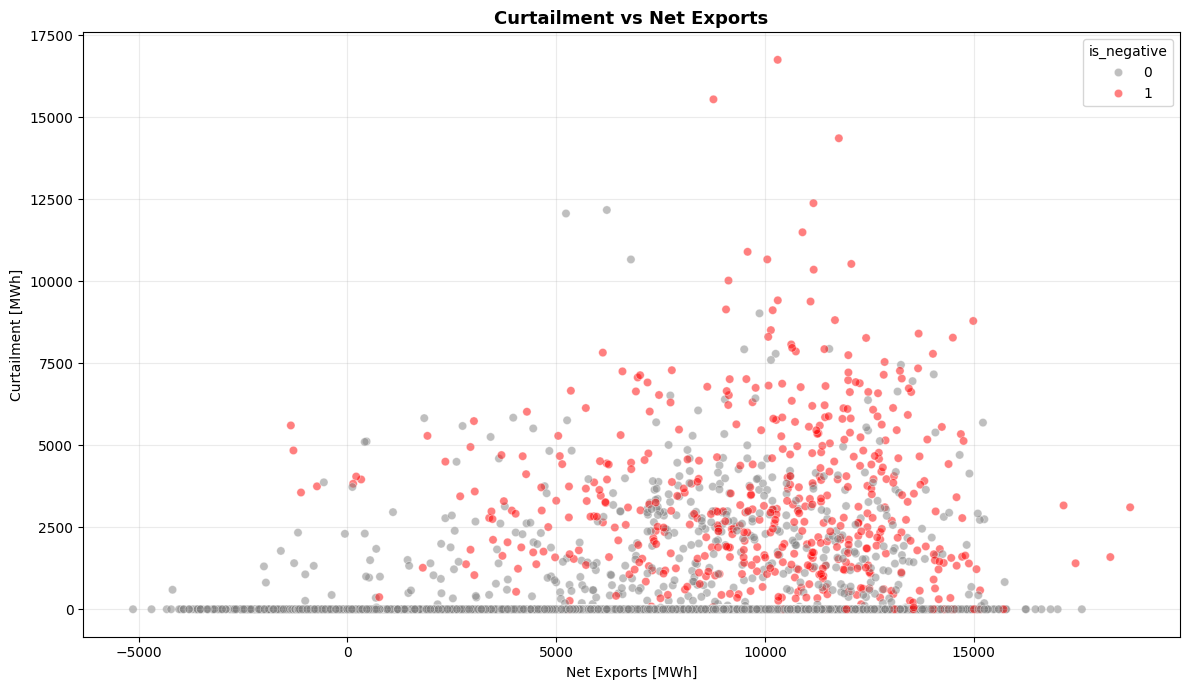

'plots/curtailment\\export_saturation_logic.png'

In [19]:
# 3. Analyse des Exports : Pour prouver la saturation physique (Réseau)
# On voit si le curtailment n'arrive que quand on exporte déjà au maximum.
pl.plot_export_saturation_curtailment(df_model)

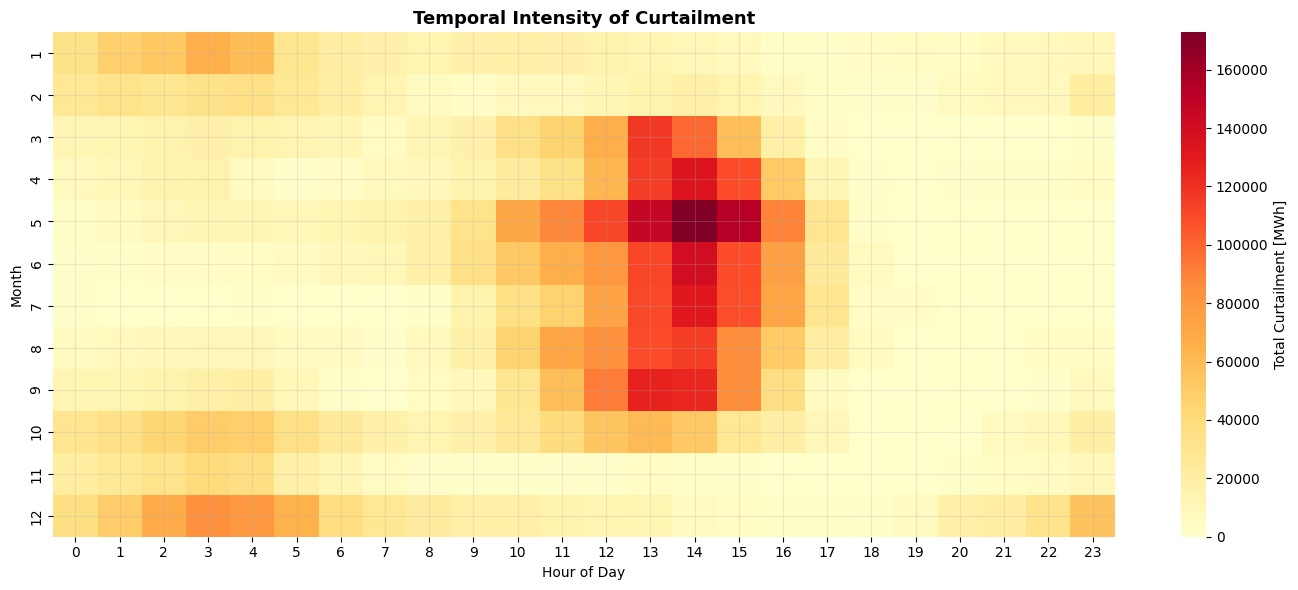

'plots/curtailment\\curtailment_seasonal_heatmap.png'

In [20]:
# 4. Heatmap saisonnière : Pour répondre à "How often?" et "For which renewables?"
# Le solaire apparaîtra l'été à midi, l'éolien l'hiver/nuit.
pl.plot_curtailment_heatmap(df_model)

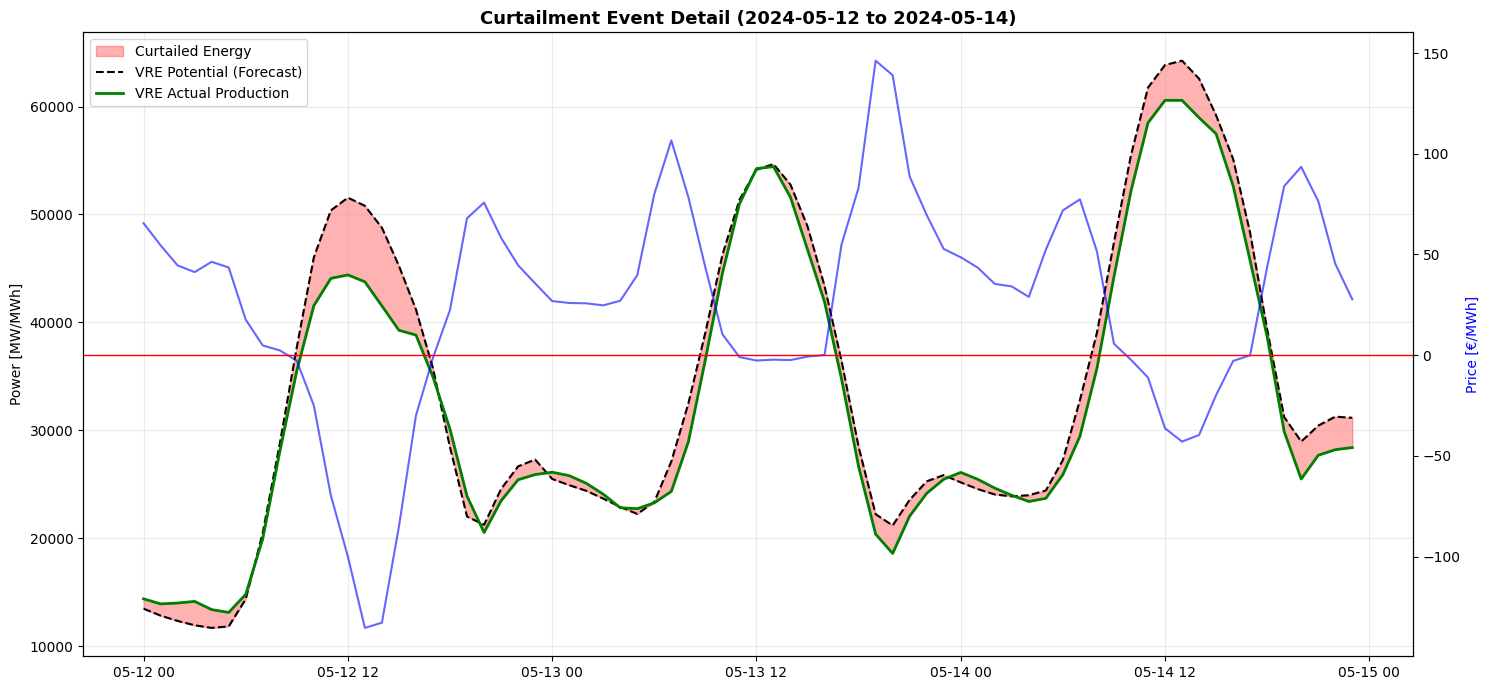

'plots/curtailment\\curtailment_event_zoom.png'

In [22]:

# 5. Zoom sur un évènement : L'illustration parfaite pour ton rapport
# Choisis une date où tu sais qu'il y a eu un gros prix négatif (ex: Mai 2024)
pl.plot_curtailment_event_zoom(df_model, "2024-05-12", "2024-05-14")